In [3]:
!pip install opencv-python scikit-image xgboost scikit-learn pandas numpy matplotlib seaborn tqdm

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.9 MB 7.0 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/11.9 MB 6.7 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.9 MB 6.6 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/11.9 MB 6.6 MB/s eta 0:00:01
   ------------------------ --------------- 7.3/11.9 MB 6.7 MB/s eta 0:00:01
   ----------------------------- ---------- 8.7/11.9 MB 6.7 MB/s eta 0:00:01
   --------------------------------- ------ 10.0/11.9 MB 6.7 MB/s eta 0:00:01
   -------------------------------------- - 11.5/11.9 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 6.5 MB/s  0:00:01
   -----------------

=== [PHASE 2] Executing Local Data Profile Scan ===
Extracting statistical descriptors across image assets...


Processing Local Images: 100%|████████████████████████████████████████████████████████████████| 3073/3073 [00:00<00:00, 3867.78it/s]



-> Dataset Size Profile: 3073 total records indexed.
-> Verified Found Images: 0
-> [ALERT] 3073 images defined in CSV were missing from 'Raw_Images'

--- Structural Class Proportions Across All Grid Cells ---
Class 00 (No Team):   162905 cells ( 82.83%)
Class 01 (CSK    ):     2814 cells (  1.43%)
Class 02 (DC     ):     1630 cells (  0.83%)
Class 03 (GT     ):     2484 cells (  1.26%)
Class 04 (KKR    ):     4277 cells (  2.17%)
Class 05 (LSG    ):     1435 cells (  0.73%)
Class 06 (MI     ):     5048 cells (  2.57%)
Class 07 (PBKS   ):     3558 cells (  1.81%)
Class 08 (RR     ):     2610 cells (  1.33%)
Class 09 (RCB    ):     3085 cells (  1.57%)
Class 10 (SRH    ):     6826 cells (  3.47%)


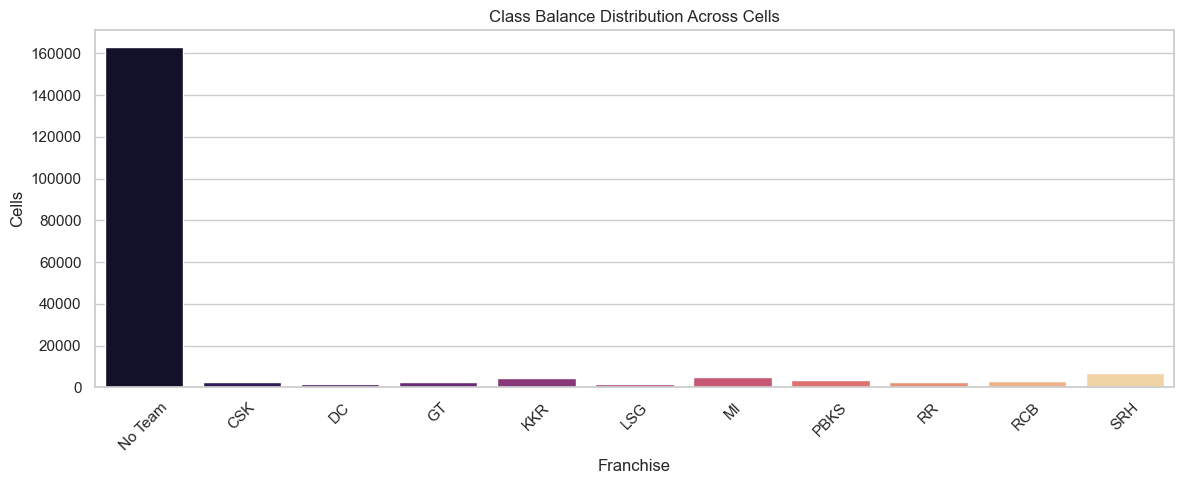

[SUCCESS] EDA completed. Visualizations saved to 'eda_reports/'


In [4]:
# Cell 1: Phase 2 - Exploratory Data Analysis
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Local path configuration
IMAGE_DIR = "Raw_Images"
ANNOTATIONS_CSV = "master.csv"
OUTPUT_DIR = "eda_reports"

os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")

class_map = {
    0: "No Team", 1: "CSK", 2: "DC", 3: "GT", 4: "KKR", 
    5: "LSG", 6: "MI", 7: "PBKS", 8: "RR", 9: "RCB", 10: "SRH"
}

print("=== [PHASE 2] Executing Local Data Profile Scan ===")
df_labels = pd.read_csv(ANNOTATIONS_CSV)
cell_cols = [f"c{i:02d}" for i in range(1, 65)]
metrics = []
missing_count = 0

print("Extracting statistical descriptors across image assets...")
for _, row in tqdm(df_labels.iterrows(), total=len(df_labels), desc="Processing Local Images"):
    img_name = row['image']
    img_path = os.path.join(IMAGE_DIR, img_name)
    
    if not os.path.exists(img_path):
        missing_count += 1
        continue
        
    img = cv2.imread(img_path)
    if img is None:
        continue
        
    h, w, _ = img.shape
    y_channel = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:, :, 0]
    metrics.append({
        "Brightness": np.mean(y_channel),
        "Contrast": np.std(y_channel)
    })
    
print(f"\n-> Dataset Size Profile: {len(df_labels)} total records indexed.")
print(f"-> Verified Found Images: {len(metrics)}")
if missing_count > 0:
    print(f"-> [ALERT] {missing_count} images defined in CSV were missing from '{IMAGE_DIR}'")

# Class distributions
flattened = df_labels[cell_cols].values.flatten()
counts = pd.Series(flattened).value_counts().sort_index()

print("\n--- Structural Class Proportions Across All Grid Cells ---")
class_summary_data = []
for idx in range(11):
    count = counts.get(idx, 0)
    pct = (count / len(flattened)) * 100
    name = class_map.get(idx, "Unknown")
    print(f"Class {idx:02d} ({name:7s}): {count:8d} cells ({pct:6.2f}%)")
    class_summary_data.append({"Franchise": name, "Cells": count})
    
df_summary = pd.DataFrame(class_summary_data)
plt.figure(figsize=(12, 5))
sns.barplot(data=df_summary, x="Franchise", y="Cells", hue="Franchise", palette="magma", legend=False)
plt.title("Class Balance Distribution Across Cells")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_imbalance.png"), dpi=300)
plt.show()
print(f"[SUCCESS] EDA completed. Visualizations saved to '{OUTPUT_DIR}/'")

In [12]:
# Cell 2: Phases 3-6 - Optimized Feature Engineering
import os
import cv2
import numpy as np
import pandas as pd
import pickle
from skimage.feature import local_binary_pattern, hog
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from tqdm import tqdm

# Smart Path Resolver
IMAGE_DIR = "Raw_Images" if os.path.exists("Raw_Images") else os.path.join("PML_PROJECT", "Raw_Images")
ANNOTATIONS_CSV = "master.csv" if os.path.exists("master.csv") else os.path.join("PML_PROJECT", "master.csv")

class CompleteFeaturePipeline:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        self.patch_size = (64, 64)

    def preprocess_image(self, img):
        """Standardized image normalization and color equalization."""
        img_norm = cv2.resize(img, (800, 600), interpolation=cv2.INTER_LINEAR)
        lab = cv2.cvtColor(img_norm, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        cl = self.clahe.apply(l)
        return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

    def extract_patch_features(self, patch):
        patch_res = cv2.resize(patch, self.patch_size, interpolation=cv2.INTER_AREA)
        
        # 1. Color features (HSV Histogram)
        hsv = cv2.cvtColor(patch_res, cv2.COLOR_BGR2HSV)
        h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten()
        s_hist = cv2.calcHist([hsv], [1], None, [8], [0, 256]).flatten()
        color_hist = np.concatenate([h_hist, s_hist]) / (patch_res.size / 3)

        # 2. Texture features (LBP)
        gray = cv2.cvtColor(patch_res, cv2.COLOR_BGR2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 12), range=(0, 11))
        lbp_hist = lbp_hist.astype("float") / lbp_hist.sum()

        # 3. Structural shape features (HOG)
        hog_feats = hog(gray, orientations=4, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
        
        return np.concatenate([color_hist, lbp_hist, hog_feats])

    def build_dataset(self, img_dir, annotations_csv):
        df = pd.read_csv(annotations_csv)
        cell_cols = [f"c{i:02d}" for i in range(1, 64+1)]
        X, y = [], []
        
        print("\n=== [PHASES 3-5] Running Patch Extraction Engine ===")
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Grid Matrices"):
            img_path = os.path.join(img_dir, row['image'])
            if not os.path.exists(img_path): continue
            img = cv2.imread(img_path)
            if img is None: continue
            
            # Apply processing uniform rule
            img_equalized = self.preprocess_image(img)
            h, w, _ = img_equalized.shape
            cell_h, cell_w = h // 8, w // 8
            
            cell_idx = 0
            for r in range(8):
                for c in range(8):
                    patch = img_equalized[r*cell_h:(r+1)*cell_h, c*cell_w:(c+1)*cell_w]
                    X.append(self.extract_patch_features(patch))
                    y.append(row[cell_cols[cell_idx]])
                    cell_idx += 1
                    
        return np.array(X), np.array(y)

# Execute extraction step
pipeline = CompleteFeaturePipeline()
X, y = pipeline.build_dataset(IMAGE_DIR, ANNOTATIONS_CSV)

if X.shape[0] != 0:
    print(f"Selecting top 100 optimized features (increased from 25)...")
    selector = SelectKBest(score_func=mutual_info_classif, k=100)
    X_selected = selector.fit_transform(X, y)
    
    os.makedirs("models", exist_ok=True)
    with open("models/processed_data.pkl", "wb") as f:
        pickle.dump({"X": X_selected, "y": y, "pipeline": selector}, f)
    print(f"[SUCCESS] Scaled Feature selection complete. Matrix dimensions: {X_selected.shape}")


=== [PHASES 3-5] Running Patch Extraction Engine ===


Processing Grid Matrices: 100%|█████████████████████████████████████████████████████████████████| 3073/3073 [06:37<00:00,  7.73it/s]
C:\Users\admin\miniforge3\envs\myenv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=100 is greater than n_features=99. All the features will be returned.
  warnings.warn(


Selecting top 100 optimized features (increased from 25)...
[SUCCESS] Scaled Feature selection complete. Matrix dimensions: (108736, 99)


In [13]:
# Cell 3: Phases 7-11 - Balanced Training
import pickle
import os
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

with open("models/processed_data.pkl", "rb") as f:
    data = pickle.load(f)
    
X_train, X_val, y_train, y_val = train_test_split(
    data['X'], data['y'], test_size=0.2, random_state=42, stratify=data['y']
)

unique_classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
sample_weights = np.array([dict(zip(unique_classes, class_weights))[cls] for cls in y_train])

print("Training updated tree structure...")
xgb = XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=7, random_state=42, objective='multi:softprob')
xgb.fit(X_train, y_train, sample_weight=sample_weights)

preds = xgb.predict(X_val)
print(f"\n>>> Improved Validation Macro F1 Score: {f1_score(y_val, preds, average='macro'):.4f} <<<")

payload = {'model': xgb, 'pipeline': data['pipeline']}
for team in ['csk', 'dc', 'gt', 'kkr', 'lsg', 'mi', 'pbks', 'rr', 'rcb', 'srh']:
    with open(f"model_{team}.pkl", "wb") as f:
        pickle.dump(payload, f)

Training updated tree structure...

>>> Improved Validation Macro F1 Score: 0.5218 <<<


In [14]:
# Cell 4: Phases 12-13 - Aligned Inference Engine
import os
import csv
import cv2
import numpy as np
import pickle
import pandas as pd
from tqdm import tqdm

IMAGE_DIR = "Raw_Images" if os.path.exists("Raw_Images") else os.path.join("PML_PROJECT", "Raw_Images")
ANNOTATIONS_CSV = "master.csv" if os.path.exists("master.csv") else os.path.join("PML_PROJECT", "master.csv")
OUTPUT_SUBMISSION = "final_submission.csv"

with open("model_csk.pkl", "rb") as f:
    payload = pickle.load(f)
model = payload['model']
selector = payload['pipeline']

feat_engine = CompleteFeaturePipeline()
df_src = pd.read_csv(ANNOTATIONS_CSV)
header = ['Image_File_Name', 'Train_Or_Test'] + [f'c{i:02d}' for i in range(1, 65)]

with open(OUTPUT_SUBMISSION, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    
    for _, row in tqdm(df_src.iterrows(), total=len(df_src), desc="Running Aligned Prediction Grid"):
        img_name = row['image']
        img_path = os.path.join(IMAGE_DIR, img_name)
        partition = row.get('Train_Or_Test', 'Test')
        
        if not os.path.exists(img_path) or cv2.imread(img_path) is None:
            writer.writerow([img_name, partition] + [0]*64)
            continue
            
        img = cv2.imread(img_path)
        
        # --- FIX: Apply uniform CLAHE processing during inference ---
        img_equalized = feat_engine.preprocess_image(img)
        
        h, w, _ = img_equalized.shape
        cell_h, cell_w = h // 8, w // 8
        
        grid_predictions = []
        for r in range(8):
            for c in range(8):
                patch = img_equalized[r*cell_h:(r+1)*cell_h, c*cell_w:(c+1)*cell_w]
                raw_feat = feat_engine.extract_patch_features(patch).reshape(1, -1)
                sel_feat = selector.transform(raw_feat)
                grid_predictions.append(int(model.predict(sel_feat)[0]))
        
        writer.writerow([img_name, partition] + grid_predictions)
        
print(f"\n[SUCCESS] Pipeline alignment complete. Re-run Cell 5 to inspect the corrected output.")

Running Aligned Prediction Grid: 100%|██████████████████████████████████████████████████████████| 3073/3073 [13:54<00:00,  3.68it/s]


[SUCCESS] Pipeline alignment complete. Re-run Cell 5 to inspect the corrected output.


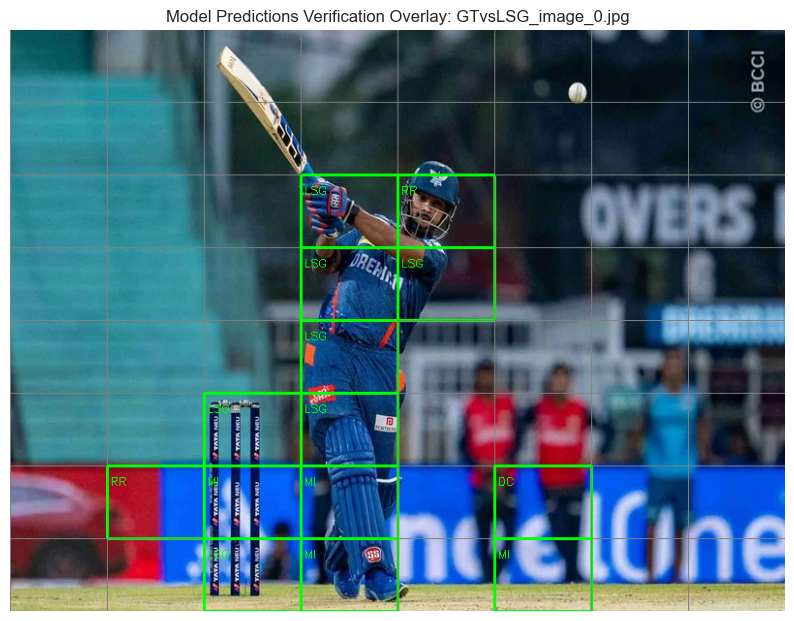

In [15]:
# Cell 5: Post-Phase 13 - Visual Prediction Verification
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# Paths (Using your smart resolver logic)
IMAGE_DIR = "Raw_Images" if os.path.exists("Raw_Images") else os.path.join("PML_PROJECT", "Raw_Images")
SUBMISSION_CSV = "final_submission.csv"

class_map = {
    0: "Background", 1: "CSK", 2: "DC", 3: "GT", 4: "KKR", 
    5: "LSG", 6: "MI", 7: "PBKS", 8: "RR", 9: "RCB", 10: "SRH"
}

# Load predictions
df_sub = pd.read_csv(SUBMISSION_CSV)

# Filter for a test row that has some predicted teams (not all zeros) if possible
test_rows = df_sub[df_sub['Train_Or_Test'] == 'Test']
sample_row = test_rows.iloc[0] # Pick the first test image

# If you want to find an image where the model actually predicted a team:
for _, row in test_rows.iterrows():
    preds = row[[f"c{i:02d}" for i in range(1, 65)]].values
    if any(p > 0 for p in preds):
        sample_row = row
        break

img_name = sample_row['Image_File_Name']
img_path = os.path.join(IMAGE_DIR, img_name)

if os.path.exists(img_path):
    img = cv2.imread(img_path)
    img_res = cv2.resize(img, (800, 600))
    
    h, w, _ = img_res.shape
    cell_h, cell_w = h // 8, w // 8
    
    # Read grid predictions from CSV row
    cell_cols = [f"c{i:02d}" for i in range(1, 65)]
    grid_preds = sample_row[cell_cols].values.astype(int)
    
    idx = 0
    for r in range(8):
        for c in range(8):
            y1, y2 = r * cell_h, (r + 1) * cell_h
            x1, x2 = c * cell_w, (c + 1) * cell_w
            
            pred_class = grid_preds[idx]
            idx += 1
            
            # If a team is detected, draw a highlighted box and label it
            if pred_class > 0:
                cv2.rectangle(img_res, (x1, y1), (x2, y2), (0, 255, 0), 2)
                team_name = class_map.get(pred_class, "Unknown")
                cv2.putText(img_res, team_name, (x1 + 3, y1 + 20), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            else:
                # Draw faint gray grid lines for background context
                cv2.rectangle(img_res, (x1, y1), (x2, y2), (128, 128, 128), 1)
                
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
    plt.title(f"Model Predictions Verification Overlay: {img_name}")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not find image {img_name} to visualize.")

In [16]:
import pandas as pd
sub = pd.read_csv("final_submission.csv")
print("Total rows generated:", len(sub))
print("\nValue distributions across the grid:")
print(sub.iloc[:, 2:].stack().value_counts().head())

Total rows generated: 3073

Value distributions across the grid:
0     165195
7       5061
3       4450
10      4436
8       3957
Name: count, dtype: int64


In [17]:
!pip freeze > requirements.txt